# AE Dataset Preparation For Predictions in Dashboard

- Historical data (2023–2025) extracted from the OMNI dataset.
- This notebook prepares the Auroral Electrojet (AE) index for machine learning forecasting.
- The final output will be a feature-engineered dataset used by the dashboard prediction system.

## Workflow

- [ ] Load AE dataset
- [ ] Inspect dataset
- [ ] Handle missing values
- [ ] Exploratory Data Analysis (EDA)
- [ ] Statistical Summary
- [ ] Autocorrelation Analysis
- [ ] Feature Engineering
- [ ] Create Lag Features
- [ ] Create Rolling Features
- [ ] Create Volatility Features
- [ ] Create Rate-of-Change Features
- [ ] Save Feature Dataset

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

In [3]:
ae_df = pd.read_csv(
    "/Users/manasstark/Desktop/PROJECTS/Space Weather Dashboard V2/data/processed/ae.csv",
    parse_dates=["datetime"],
    index_col="datetime"
)

In [4]:
ae_df.head()

,ae
datetime,
2023-01-01 00:00:00,132
2023-01-01 01:00:00,97
2023-01-01 02:00:00,133
2023-01-01 03:00:00,180
2023-01-01 04:00:00,139


In [5]:
ae_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2023-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ae      26304 non-null  int64
dtypes: int64(1)
memory usage: 411.0 KB


In [6]:
ae_df.describe()

,ae
count,26304.000000
mean,216.652334
std,213.091273
min,6.000000
25%,64.000000
50%,136.000000
75%,304.000000
max,2338.000000


In [7]:
ae_df.isna().sum()

ae    0
dtype: int64

### Missing Values

The AE dataset contains no missing values.

Therefore, no interpolation or imputation was required before feature engineering.

In [8]:
summary = pd.DataFrame({
    "Metric":[
        "Number of Observations",
        "Start Date",
        "End Date",
        "Missing Values",
        "Mean AE (nT)",
        "Median AE (nT)",
        "Minimum AE (nT)",
        "Maximum AE (nT)"
    ],
    "Value":[
        len(ae_df),
        ae_df.index.min(),
        ae_df.index.max(),
        ae_df["ae"].isna().sum(),
        round(ae_df["ae"].mean(),2),
        ae_df["ae"].median(),
        ae_df["ae"].min(),
        ae_df["ae"].max()
    ]
})

summary

,Metric,Value
0,Number of Observations,26304
1,Start Date,2023-01-01 00:00:00
2,End Date,2025-12-31 23:00:00
3,Missing Values,0
4,Mean AE (nT),216.65
5,Median AE (nT),136.0
6,Minimum AE (nT),6
7,Maximum AE (nT),2338


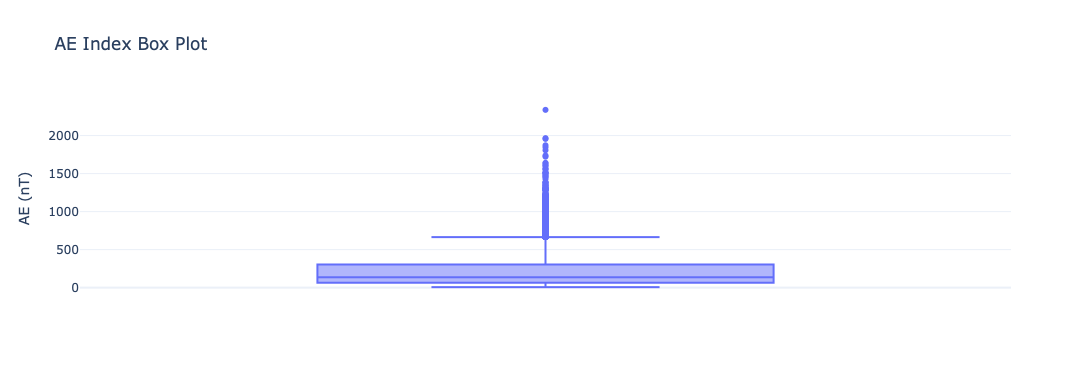

In [9]:
fig = px.box(
    ae_df,
    y="ae",
    title="AE Index Box Plot"
)

fig.update_layout(
    yaxis_title="AE (nT)",
    template="plotly_white"
)

fig.show()

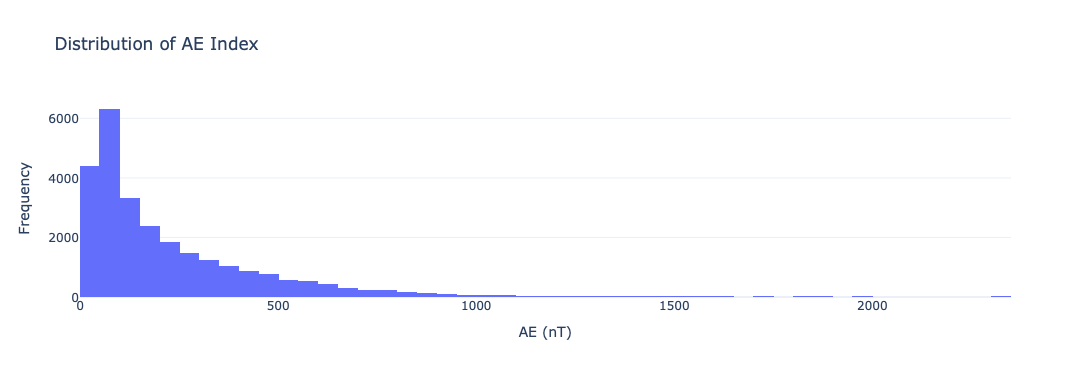

In [10]:
fig = px.histogram(
    ae_df,
    x="ae",
    nbins=50,
    title="Distribution of AE Index"
)

fig.update_layout(
    xaxis_title="AE (nT)",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

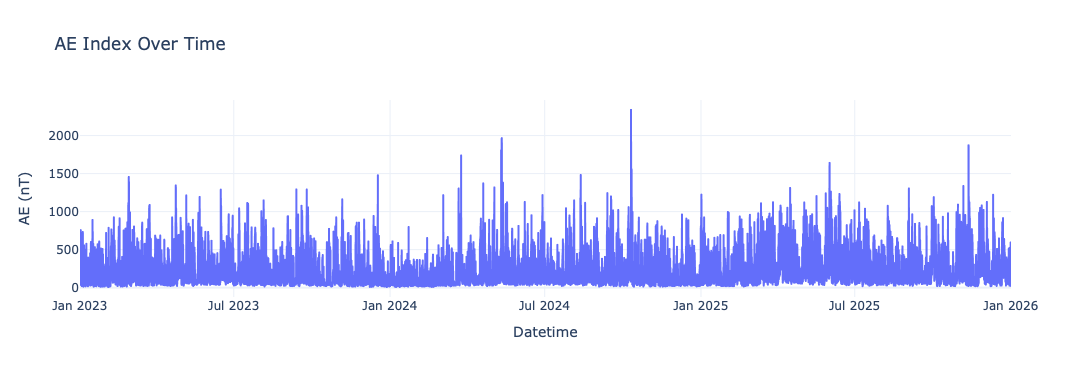

In [11]:
fig = px.line(
    ae_df,
    x=ae_df.index,
    y="ae",
    title="AE Index Over Time"
)

fig.update_layout(
    xaxis_title="Datetime",
    yaxis_title="AE (nT)",
    template="plotly_white"
)

fig.show()

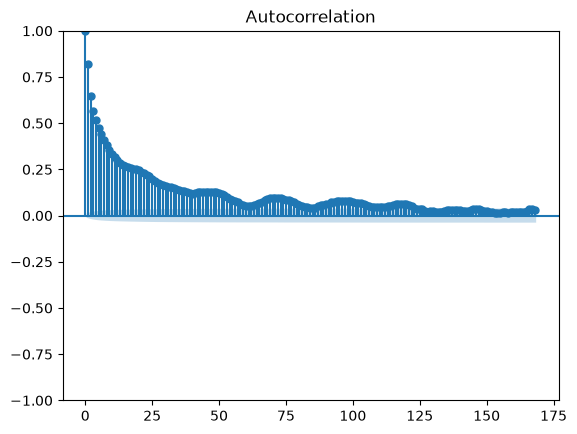

In [12]:
plot_acf(
    ae_df["ae"],
    lags=168
)

plt.show()

In [13]:
ae_features = ae_df.copy()

In [14]:
for lag in [1,3,6,12,24]:
    ae_features[f"ae_lag{lag}h"] = ae_features["ae"].shift(lag)

In [15]:
ae_features["ae_24h"] = (
    ae_features["ae"]
    .rolling(24)
    .mean()
)

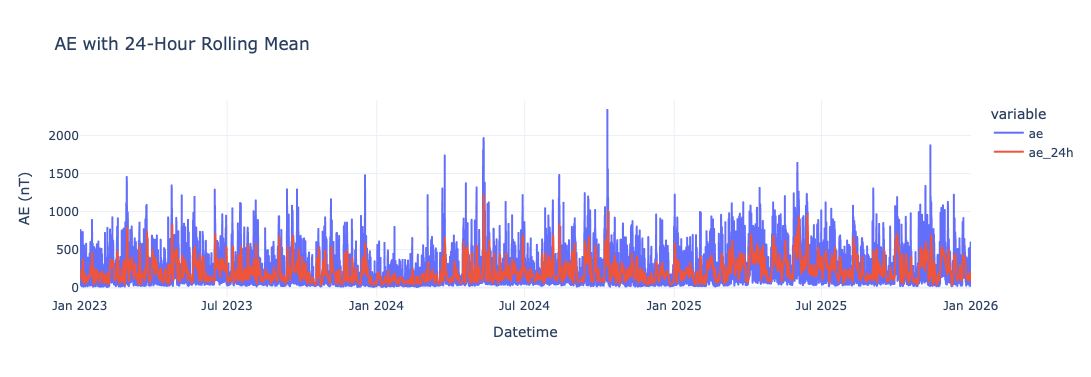

In [16]:
ae_df["ae_24h"] = ae_df["ae"].rolling(24).mean()

fig = px.line(
    ae_df,
    x=ae_df.index,
    y=["ae", "ae_24h"],
    title="AE with 24-Hour Rolling Mean"
)

fig.update_layout(
    xaxis_title="Datetime",
    yaxis_title="AE (nT)",
    template="plotly_white"
)

fig.show()

In [17]:
ae_features["ae_24h_std"] = (
    ae_features["ae"]
    .rolling(24)
    .std()
)

In [18]:
ae_features["ae_change"] = (
    ae_features["ae"]
    .diff()
)

In [19]:
ae_features = ae_features.dropna().copy()

In [20]:
ae_features.head()

,ae,ae_lag1h,ae_lag3h,ae_lag6h,ae_lag12h,ae_lag24h,ae_24h,ae_24h_std,ae_change
datetime,,,,,,,,,
2023-01-02 00:00:00,153,222.0,257.0,370.0,42.0,132.0,224.458333,162.987057,-69.0
2023-01-02 01:00:00,90,153.0,199.0,487.0,82.0,97.0,224.166667,163.231142,-63.0
2023-01-02 02:00:00,73,90.0,222.0,756.0,153.0,133.0,221.666667,165.136483,-17.0
2023-01-02 03:00:00,62,73.0,153.0,257.0,375.0,180.0,216.750000,168.159926,-11.0
2023-01-02 04:00:00,72,62.0,90.0,199.0,200.0,139.0,213.958333,170.052288,10.0


In [21]:
ae_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26280 entries, 2023-01-02 00:00:00 to 2025-12-31 23:00:00
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ae          26280 non-null  int64  
 1   ae_lag1h    26280 non-null  float64
 2   ae_lag3h    26280 non-null  float64
 3   ae_lag6h    26280 non-null  float64
 4   ae_lag12h   26280 non-null  float64
 5   ae_lag24h   26280 non-null  float64
 6   ae_24h      26280 non-null  float64
 7   ae_24h_std  26280 non-null  float64
 8   ae_change   26280 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 2.0 MB


In [22]:
ae_features.isna().sum()

ae            0
ae_lag1h      0
ae_lag3h      0
ae_lag6h      0
ae_lag12h     0
ae_lag24h     0
ae_24h        0
ae_24h_std    0
ae_change     0
dtype: int64

In [24]:
ae_features.to_csv(
    "/Users/manasstark/Desktop/PROJECTS/Space Weather Dashboard V2/data/ae_features.csv"
)